
RQ7 TABLE:

                     Accuracy
Random Forest        0.823667
KNN                  0.587333
SVM                  0.527667
Logistic Regression  0.227333

Best Model: Random Forest
Accuracy: 0.8237


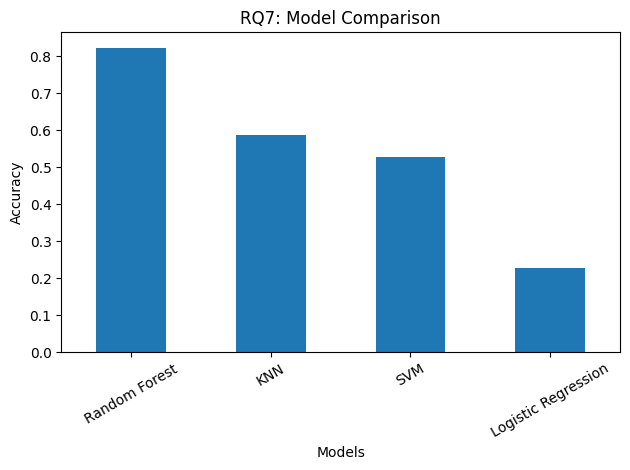


Files saved in: C:\Users\vishwa\kidney disease prediction/outputs/


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score


# =========================
# 0. OUTPUT FOLDER
# =========================
os.makedirs("outputs", exist_ok=True)


# =========================
# 1. LOAD DATA
# =========================
df = pd.read_csv("kidney_disease_balanced.csv")
df.replace('?', np.nan, inplace=True)


# =========================
# 2. SPLIT TARGET
# =========================
y = df["Target"]
X = df.drop("Target", axis=1)


# =========================
# 3. DETECT COLUMNS
# =========================
cat_cols = X.select_dtypes(include=['str']).columns

if len(cat_cols) == 0:
    cat_cols = X.select_dtypes(include=['str']).columns

num_cols = X.columns.difference(cat_cols)


# =========================
# 4. PREPROCESSING
# =========================
# Impute
X[num_cols] = SimpleImputer(strategy='mean').fit_transform(X[num_cols])
X[cat_cols] = SimpleImputer(strategy='most_frequent').fit_transform(X[cat_cols])

# Encode categorical
le = LabelEncoder()
for col in cat_cols:
    X[col] = le.fit_transform(X[col])

# Encode target
y = LabelEncoder().fit_transform(y)

# Scale
X = StandardScaler().fit_transform(X)


# =========================
# 5. TRAIN-TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# =========================
# 6. MODELS
# =========================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier()
}


results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc


# =========================
# 7. CREATE TABLE
# =========================
df_out = pd.DataFrame.from_dict(
    results, orient='index', columns=["Accuracy"]
)

df_out = df_out.sort_values(by="Accuracy", ascending=False)

df_out.to_csv("outputs/RQ7_table.csv")

print("\nRQ7 TABLE:\n")
print(df_out)


# =========================
# 8. BEST MODEL
# =========================
best_model_name = df_out.index[0]
best_accuracy = df_out.iloc[0]["Accuracy"]

print(f"\nBest Model: {best_model_name}")
print(f"Accuracy: {best_accuracy:.4f}")


# =========================
# 9. CREATE FIGURE
# =========================
plt.figure()

df_out["Accuracy"].plot(kind="bar")

plt.title("RQ7: Model Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Models")

plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig("outputs/RQ7_figure.pdf")

plt.show()


# =========================
# 10. CONFIRM SAVE
# =========================
print("\nFiles saved in:", os.getcwd() + "/outputs/")